# Application 2 — LLM-based text analysis

* * *

In *Application 1* we built sentiment models three ways: off-the-shelf tools, a tf-idf classifier we trained ourselves, and a fine-tuned DistilBERT. That last step quietly introduced a **Transformer** — we used it as a black box and just watched the accuracy go up.

This notebook opens that black box. The goal is not to make you a deep-learning engineer, but to give you enough of a mental model that you can:

- read a `transformers` code snippet and know *what each piece is doing*,
- tell **BERT**, **GPT**, and **BART** apart and pick the right one for a task,
- understand what a **Large Language Model (LLM)** actually is, and
- call an LLM through an **API** to solve real NLP problems — classification, scoring, summarization, generation, and Q&A — with a few lines of code.

# Setup

These are the libraries we use in Parts 1–3. On Colab, uncomment the install line and run it once.

In [1]:
# On Colab, run this once:
# !pip install -q transformers torch matplotlib numpy

import os, warnings
warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"   # quieter model downloads

import numpy as np
import matplotlib.pyplot as plt
import torch

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()                    # hide load reports / warnings

print("torch", torch.__version__)
print("GPU available:", torch.cuda.is_available())

torch 2.10.0
GPU available: False


# Part 1 — A short history of representing language

Every NLP method, old or new, has to answer one question first:

> **How do we turn a piece of text into something a computer can compute with?**

The whole history of NLP is a sequence of better answers to that question. Each era fixed a weakness of the previous one.

<img src='./images/history.png' alt="history" width="1200">


# Part 2 — Inside the Transformer

The Transformer is the engine under BERT, GPT, BART, and every modern LLM. A full Transformer layer has several parts, but **self-attention** is the heart of it. We'll build that from scratch, then look at the supporting parts you should also recognize.

<img src='./images/transformer2.png' alt="transformer" width="500">


Image from [here](https://www.interdb.jp/dl/part04/ch15/sec03.html)



## 2.1  Tokenization

Before any math, text has to become numbers. Modern Transformers don't split on whitespace; they use **subword** tokenization (BPE / WordPiece). Frequent words stay whole; rare words break into reusable pieces. This keeps the vocabulary small while still being able to represent *any* word — even ones never seen in training.

In [4]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("bert-base-uncased")

for w in ["playing", "unbelievable", "tokenization", "antidisestablishmentarianism", "COVID-19"]:
    print(f"{w:32s} -> {tok.tokenize(w)}")

print()
enc = tok("The cat sat.", return_tensors="pt")
print("input_ids:", enc["input_ids"].tolist())
print("tokens   :", tok.convert_ids_to_tokens(enc["input_ids"][0]))

playing                          -> ['playing']
unbelievable                     -> ['unbelievable']
tokenization                     -> ['token', '##ization']
antidisestablishmentarianism     -> ['anti', '##dis', '##est', '##ab', '##lish', '##ment', '##arian', '##ism']
COVID-19                         -> ['co', '##vid', '-', '19']

input_ids: [[101, 1996, 4937, 2938, 1012, 102]]
tokens   : ['[CLS]', 'the', 'cat', 'sat', '.', '[SEP]']


Notice `##` marks a piece glued onto the previous token, and the tokenizer auto-adds special tokens `[CLS]` (start) and `[SEP]` (end) 

## 2.2  Self-attention from scratch

Here is the one idea to really understand. For each word, self-attention builds a **new representation by mixing in information from the other words**, weighted by how relevant each one is. 

<img src='./images/similarity.png' alt="s" width="1000">

Image from [here](http://medium.com/@ramendrakumar/self-attention-d8196b9e9143)


**Step 1 — project each token into Q, K, V.** Start from the input embeddings `X` of shape
`(N, d_model)` for `N` tokens, and multiply by three learned matrices:

```
Q = X @ W_q     (N, d_k) # Query  (Q)  — "what am I looking for?"
K = X @ W_k     (N, d_k) # Key    (K)  — "what each token is labeled as"
V = X @ W_v     (N, d_v) # Value  (V)  — "what content do I pass on if attended to?"
```
**Step 2 — similarity by dot product.** Compare every token's Query with every token's Key:

```
scores = Q @ Kᵀ / √d_k        (N, N)
```
`scores[i, j]` = how much token *i* should attend to token *j*. 

**Step 3 — softmax → weights.** Turn each row of scores into mixing weights that sum to 1:

```
A = softmax(scores, axis=-1)      (N, N), each row sums to 1
Row *i* now reads: "to build my new vector, take 90% from this token, 4% from that one, …".
```

**Step 4 — weighted Value vectors.** Each token's new vector is a **weighted average of the Value vectors**. For the row of *cat* below:
```
        the    cat    sat
cat  [  0.06   0.04   0.90 ]
out_cat = 0.06 · V_the  +  0.04 · V_cat  +  0.90 · V_sat
```

<img src='./images/scores.png' alt="scores" width="1000">

Image from [here](https://www.cnblogs.com/hbuwyg/p/16978264.html)





In [ ]:
# Numpy implementation
import numpy as np
np.random.seed(0)

tokens = ["the", "cat", "sat"]
d_model, d_k = 4, 4

X   = np.random.randn(3, d_model)        # each token already embedded as a 4-d vector
W_q = np.random.randn(d_model, d_k)      # learned in a real model
W_k = np.random.randn(d_model, d_k)
W_v = np.random.randn(d_model, d_k)

Q = X @ W_q      # (3, d_k)  what each token looks for
K = X @ W_k      # (3, d_k)  what each token is labeled as
V = X @ W_v      # (3, d_k)  content to pass on

def softmax(z):
    e = np.exp(z - z.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

scores = Q @ K.T / np.sqrt(d_k)          # (3, 3)
attn   = softmax(scores)                  # rows sum to 1
out    = attn @ V                          # (3, d_k) new representations

print("attention weights (row i = how token i attends to each token):")
print("        ", "   ".join(tokens))
for t, row in zip(tokens, attn):
    print(f"{t:>6}  ", "  ".join(f"{w:.2f}" for w in row))

print("\nrow sums (should be 1):", attn.sum(axis=1).round(3))
print("output shape:", out.shape)

attention weights (row i = how token i attends to each token):
         the   cat   sat
   the   0.00  1.00  0.00
   cat   0.06  0.04  0.90
   sat   0.07  0.91  0.01

row sums (should be 1): [1. 1. 1.]
output shape: (3, 4)


## 2.3  The same attention, in a real model

The toy version above is *exactly* what a trained model does — just with learned weights and many layers/heads. We can pull the real attention weights out of a pre-trained model and visualize them. Watch which words the model links together.

<img src='./images/transformer2.png' alt="transformer" width="400">
<img src='./images/attention-heads.png' alt="attention-head" width="700">

Image from [here](https://www.interdb.jp/dl/part04/ch15/sec03.html)



In [6]:
from transformers import AutoTokenizer, AutoModel
import torch

name = "distilbert-base-uncased"
tok2 = AutoTokenizer.from_pretrained(name)
model = AutoModel.from_pretrained(name, attn_implementation="eager", output_attentions=True)
model.eval()

sentence = "The animal didn't cross the street because it was too tired"
enc = tok2(sentence, return_tensors="pt")
with torch.no_grad():
    out = model(**enc)

# out.attentions: tuple(num_layers) of (batch, num_heads, seq, seq)
attn_last = out.attentions[-1][0].mean(0).numpy()   # last layer, averaged over heads
labels = tok2.convert_ids_to_tokens(enc["input_ids"][0])
print("layers:", len(out.attentions), "| heads per layer:", out.attentions[0].shape[1])
print("attention matrix shape:", attn_last.shape)

layers: 6 | heads per layer: 12
attention matrix shape: (15, 15)


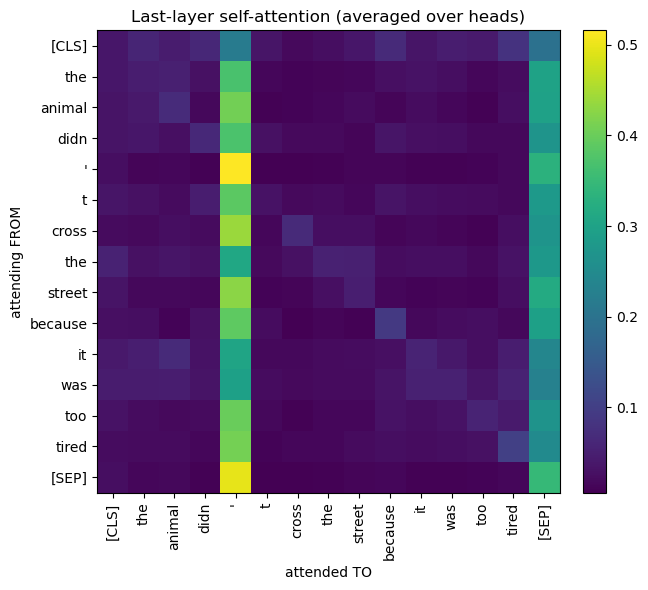

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attn_last, cmap="viridis")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("attended TO"); ax.set_ylabel("attending FROM")
ax.set_title("Last-layer self-attention (averaged over heads)")
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 2.4  The other pieces to recognize

Self-attention is the core, but a real Transformer block wraps it in a few more parts. 
- **Positional encoding.** Attention by itself is order-blind — shuffle the words and the math is identical. So we *add* a position signal to each token embedding, telling the model where each word sits. This is how the Transformer recovers the word-order information that RNNs got for free.
- **Feed-forward + residual + LayerNorm.** After attention mixes information *across* tokens, a small network transforms each token on its own; residual connections and normalization keep the deep stack trainable.
- **Encoder vs. decoder blocks.** Two ways to wire the attention. **BERT is a stack of encoder blocks, GPT is a stack of decoder blocks, and BART uses both.**


If you want to read a clean, top-to-bottom implementation rather than production code:

- **The Annotated Transformer** (Harvard NLP) — the original 2017 paper rebuilt line-by-line in PyTorch, encoder + decoder + cross-attention: <https://nlp.seas.harvard.edu/annotated-transformer/>
- **nanoGPT** (Andrej Karpathy) — a tiny, very readable decoder-only GPT (~300 lines): <https://github.com/karpathy/nanoGPT>
- **The original paper** — *"Attention Is All You Need"*, Vaswani et al., 2017: <https://arxiv.org/abs/1706.03762>

# Part 3 — BERT, GPT, BART

Same Transformer engine, three different wirings, three different jobs.

```
   ┌───────────────────────────────────────────────────────────────┐
   │  BERT     ENCODER-only      bidirectional   →  UNDERSTAND text  │
   │           (2018, Google)    fill-in-blanks     classify, embed  │
   ├───────────────────────────────────────────────────────────────┤
   │  GPT      DECODER-only      left-to-right    →  GENERATE text    │
   │           (2018, OpenAI)    predict next        write, chat      │
   ├───────────────────────────────────────────────────────────────┤
   │  BART     ENCODER+DECODER   read then write  →  TRANSFORM text   │
   │           (2019, Meta)      seq-to-seq          summarize, trans │
   └───────────────────────────────────────────────────────────────┘
```

## 3.1  BERT — the encoder (understanding)

BERT reads the **whole sentence at once** (bidirectional). It's pre-trained by **masking** random words and asking the model to fill them in — which forces it to build rich, context-aware representations. That makes BERT great for *understanding* tasks (classification, embeddings) — it's exactly the model we fine-tuned in Application 1.

We can see the masked-language-model objective directly with the `fill-mask` pipeline.

In [15]:
from transformers import pipeline

fill = pipeline("fill-mask", model="distilbert-base-uncased")

for s in ["Paris is the [MASK] of France.",
          "The movie was absolutely [MASK].",
          "I deposited my paycheck at the [MASK]."]:
    top = fill(s)[0]
    print(f"{s:45s} -> {top['token_str']!r:14s} ({top['score']:.2f})")

Paris is the [MASK] of France.                -> 'capital'      (0.98)
The movie was absolutely [MASK].              -> 'fantastic'    (0.11)
I deposited my paycheck at the [MASK].        -> 'bank'         (0.14)


## 3.2  GPT — the decoder (generation)

GPT flips the objective: predict the **next** token given everything to the left. A causal mask hides the future, so the model can only look backward — which is precisely what you need to *generate* text one token at a time. Run it and watch it continue a prompt.

In [17]:
from transformers import pipeline, set_seed

gen = pipeline("text-generation", model="gpt2")
set_seed(42)

prompt = "Social scientists use natural language processing to"
out = gen(prompt, max_new_tokens=40, num_return_sequences=1, pad_token_id=50256)
print(out[0]["generated_text"])

Social scientists use natural language processing to understand how humans use social networks. In other words, they use natural language processing to learn about those who like what they see and to interact with them.

People are learning new things when they


## 3.3  BART — encoder + decoder (transformation)

BART glues the two together: an **encoder** reads the full input (like BERT), and a **decoder** writes a new sequence from it (like GPT). This "read it all, then write something new" shape — *sequence-to-sequence* — is ideal for tasks where output is a transformed version of the input: **summarization**, translation, paraphrase.

```
   long input ─▶ [ ENCODER: understand ] ─▶ [ DECODER: write ] ─▶ short summary
```

In [18]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

name = "sshleifer/distilbart-cnn-12-6"
stok = AutoTokenizer.from_pretrained(name)
smodel = AutoModelForSeq2SeqLM.from_pretrained(name)   # note: a *Seq2Seq* model = encoder + decoder

article = (
    "Natural language processing has moved through several eras. Early systems relied on "
    "hand-written rules, which were precise but brittle. Statistical methods then learned "
    "patterns by counting words in large corpora. Word embeddings such as word2vec mapped "
    "words to dense vectors so that similar words landed near each other. Recurrent networks "
    "added a sense of word order but struggled with long sentences. The Transformer, introduced "
    "in 2017, used attention to let every word interact with every other word in parallel, and "
    "became the foundation for BERT, GPT, and today's large language models."
)

inputs = stok(article, return_tensors="pt", truncation=True)        # encoder reads the article
summary_ids = smodel.generate(**inputs, max_length=60, min_length=20, num_beams=4)  # decoder writes
print(stok.decode(summary_ids[0], skip_special_tokens=True).strip())

Early systems relied on hand-written rules, which were precise but brittle . Statistical methods learned patterns by counting words in large corpora . Recurrent networks added a sense of word order but struggled with long sentences . Transformer, introduced in 2017, used attention to let every word interact with


# Part 4 — Large Language Models and the API

Modern general-purpose **LLMs are almost all decoder-only** — it turns out that with enough scale, a pure next-token predictor can also classify, summarize, and translate, just by being *asked* to. 

With LLMs, there is a paradigm shift in NLP research:

```
   OLD:  collect labels ─▶ fine-tune a model ─▶ deploy the model
   NEW:  write a prompt  ─▶ call an API        ─▶ read the answer
```

You no longer need a labeled dataset or a GPU for many tasks — you just describe the task in words and get answers. 

## 4.1  Connecting to the Gemini API

We'll use Google's **Gemini** API. Steps:

1. Get a free API key at <https://aistudio.google.com/apikey>.
2. Install the SDK: `pip install -q google-genai`.
3. Provide the key. **Never paste your key directly into a notebook you'll share.** On Colab, use the secrets panel (🔑 in the left sidebar) named `GEMINI_API_KEY`. Locally, set an environment variable.

In [ ]:
# On Colab, run this once:
# !pip install -q google-genai

import os
from google import genai

# --- load the key safely (Colab secret first, then environment variable) ---
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")
try:
    from google.colab import userdata
    GEMINI_API_KEY = GEMINI_API_KEY or userdata.get("GEMINI_API_KEY")
except Exception:
    pass

client = genai.Client(api_key=GEMINI_API_KEY) if GEMINI_API_KEY else None
MODEL = "gemini-2.5-flash"   # fast & cheap; use gemini-2.5-pro for harder tasks

def ask(prompt, model=MODEL):
    """Send a prompt to Gemini and return the text answer."""
    if client is None:
        return "[no API key set — see the setup cell above]"
    resp = client.models.generate_content(model=model, contents=prompt)
    return resp.text.strip()

print(ask("In one sentence, what is natural language processing?"))

## 4.2  Sentiment analysis — by prompting (zero-shot)

In Application 1 we *trained* a sentiment classifier on thousands of labeled examples. With an LLM we just *ask*. No training data, no fitting — this is **zero-shot** classification. The key skill is writing a prompt that constrains the output to something parseable.

In [ ]:
reviews = [
    "Absolutely loved it, would buy again!",
    "Terrible quality, broke after one day.",
    "It's fine I guess, nothing special.",
    "I do not dislike it.",                       # negation — tripped up TextBlob in App 1
    "Oh great, another delayed flight. Wonderful.",  # sarcasm
]

prompt = (
    "Classify each review's sentiment as POSITIVE, NEGATIVE, or NEUTRAL.\n"
    "Return one label per line, in order, with no extra text.\n\n"
    + "\n".join(f"{i+1}. {r}" for i, r in enumerate(reviews))
)

print(ask(prompt))

## 4.3  Regression — scoring on a scale

App 1 also framed sentiment as **regression**: predict a continuous Valence score. An LLM can do this too — we just ask for a number on a defined scale and parse it. We'll score a few sentences on EmoBank's 1–5 Valence scale.

In [ ]:
import re

texts = [
    "This is the best day of my life!",
    "The weather is okay today.",
    "I am devastated by the news.",
]

prompt = (
    "Rate the emotional Valence of each sentence on a 1-5 scale, where "
    "1 = very negative, 3 = neutral, 5 = very positive.\n"
    "Return only the number for each sentence, one per line.\n\n"
    + "\n".join(f"{i+1}. {t}" for i, t in enumerate(texts))
)

answer = ask(prompt)
print("raw answer:\n", answer)

# parse the numbers out of the response
scores = [float(x) for x in re.findall(r"[-+]?\d*\.?\d+", answer)]
print("\nparsed scores:", scores)

## 4.4  Summarization, generation, and Q&A

These are the tasks where LLMs really shine. In Part 3 we needed a *different model* for each (BART for summaries, GPT for generation). One LLM does all of them — you just change the instruction.

In [ ]:
article = (
    "Natural language processing has moved through several eras. Early systems relied on "
    "hand-written rules, which were precise but brittle. Statistical methods then learned "
    "patterns by counting words in large corpora. Word embeddings such as word2vec mapped "
    "words to dense vectors. Recurrent networks added a sense of word order but struggled "
    "with long sentences. The Transformer, introduced in 2017, used attention to let every "
    "word interact with every other word in parallel, and became the foundation for BERT, "
    "GPT, and today's large language models."
)

print("=== SUMMARY (in 2 bullet points) ===")
print(ask("Summarize the following in exactly 2 bullet points:\n\n" + article))

In [ ]:
print("=== GENERATION ===")
print(ask("Write a 2-sentence tweet encouraging social science students to learn NLP. "
          "Friendly tone, include one emoji."))

In [ ]:
print("=== QUESTION ANSWERING (grounded in the article) ===")
question = "According to the text, what problem did the Transformer solve, and in what year?"
print(ask(f"Answer the question using ONLY the passage below. "
          f"If the answer isn't in the passage, say so.\n\n"
          f"Passage:\n{article}\n\nQuestion: {question}"))

## 4.5  When to use an LLM API — and what to watch out for

LLMs are astonishingly general, but they are not free and not always the right tool.

**Watch out for:**

- **Cost & latency.** Every call costs money and takes ~seconds. Classifying a million documents through an API is far slower and pricier than running a fine-tuned DistilBERT or even tf-idf locally.
- **Reproducibility.** Output can vary run to run. Set a low `temperature` (or `temperature=0`) for classification/extraction; expect some drift regardless.
- **Hallucination.** The model can state false things fluently. For factual tasks, *ground* it (RAG) and verify.
- **Prompt sensitivity.** Small wording changes can shift results. Constrain the output format and test your prompt on a labeled sample.
- **Privacy.** You're sending text to a third party. Don't send sensitive data without checking your data-use agreement.

**Rule of thumb:**

```
   small labeled dataset, one-off task, need flexibility   →  LLM API (prompt it)
   huge volume, tight budget, need speed/reproducibility   →  fine-tuned small model (App 1)
   need interpretability (which words drove the decision)  →  tf-idf + linear model
```


# Final takeaways

- The history of NLP is a series of better ways to **represent text as numbers**: rules → counts → static vectors → ordered sequences → **attention**.
- The **Transformer** replaced left-to-right memory with **self-attention** (Q·K·V), letting every token see every other token in parallel — the core you implemented in NumPy and saw inside a real model.
- **BERT (encoder)** understands, **GPT (decoder)** generates, **BART (encoder-decoder)** transforms. Same engine, different wiring.
- **LLMs** are scaled-up, instruction-tuned decoders. They shift the workflow from *train a model* to *write a prompt*, and one API can do classification, scoring, summarization, generation, and Q&A.
